<a href="https://colab.research.google.com/github/Crnkcbs/money_fraud/blob/gmzbyzy/Mobile_Fraud_Analysis_Gamze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import auth
auth.authenticate_user()

In [10]:
pip install google-cloud-bigquery pandas pandas-gbq

In [11]:
import pandas as pd
from google.cloud import bigquery

# Tam tablo yolunu tanımlayın
full_table_path = 'data426-group3.dbt_gmzbyzy.mart_data426_group3__main_analysis'

# Tam tablo yolundan proje kimliğini ayıklayın
# Proje kimliği genellikle ilk bileşendir.
project_id = full_table_path.split('.')[0]

# BigQuery istemcisini (client) başlatın ve proje kimliğini belirtin
client = bigquery.Client(project=project_id)

# Çalıştırmak istediğiniz SQL sorgusu
# Sorguda doğrudan tam tablo yolunu kullanıyoruz.
query = f"""
    SELECT * FROM `{full_table_path}`
"""

# Sorguyu çalıştırın ve doğrudan Pandas DataFrame'e dönüştürün
df = client.query(query).to_dataframe()

# İlk birkaç satırı göster
print(df.head())

  transaction_id  step      type  type_code      amount amount_bucket  \
0   TX_005280320   372  TRANSFER          1  1363594.42           1M+   
1   TX_005285294   372  TRANSFER          1   947873.81       500K-1M   
2   TX_005286802   373  TRANSFER          1   228756.50     100K-500K   
3   TX_005287348   373  TRANSFER          1   539977.18       500K-1M   
4   TX_005288102   373  TRANSFER          1   284807.33     100K-500K   

   old_balance_orig  new_balance_orig  old_balance_dest  new_balance_dest  \
0               0.0               0.0        2115620.65        3479215.07   
1           40171.0               0.0              0.00         947873.81   
2               0.0               0.0        2078215.77        2306972.27   
3             186.0               0.0         878374.87        1418352.05   
4           10499.0               0.0         389420.20         674227.53   

   is_fraud  is_flagged_fraud  is_merchant_dest  is_customer_dest  \
0         0                 0

# İşlem Tutarı (Miktar) ve Dolandırıcılık Analizi

Dolandırıcılık işlemlerinin işlem tutarı (amount) dağılımı normal işlemlerden farklı mı?

In [12]:
df['is_fraud'] = df['is_fraud'].astype(int)

# Log dönüşüm (çok önemli çünkü amount skewed)
import numpy as np
df['log_amount'] = np.log1p(df['amount'])

In [13]:
df.groupby('is_fraud')['amount'].agg(['mean','median','count'])

,mean,median,count
is_fraud,,,
0,1.781970e+05,74684.72,6354407
1,1.467967e+06,441423.44,8213


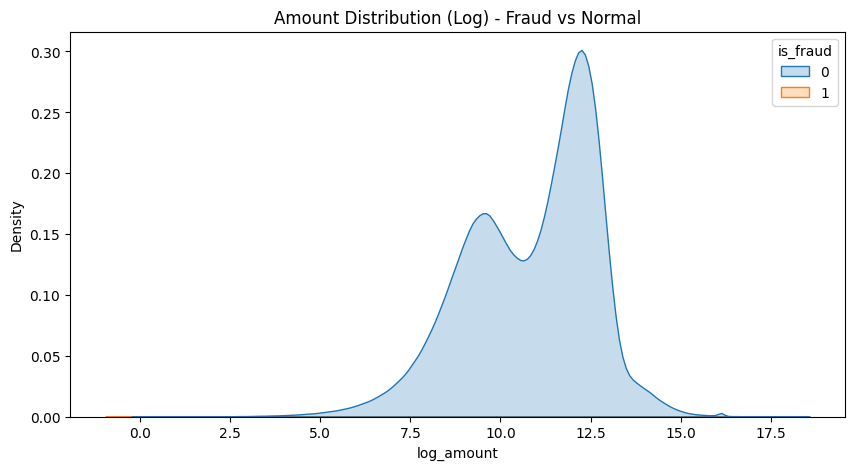

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='log_amount', hue='is_fraud', fill=True)
plt.title("Amount Distribution (Log) - Fraud vs Normal")
plt.show()

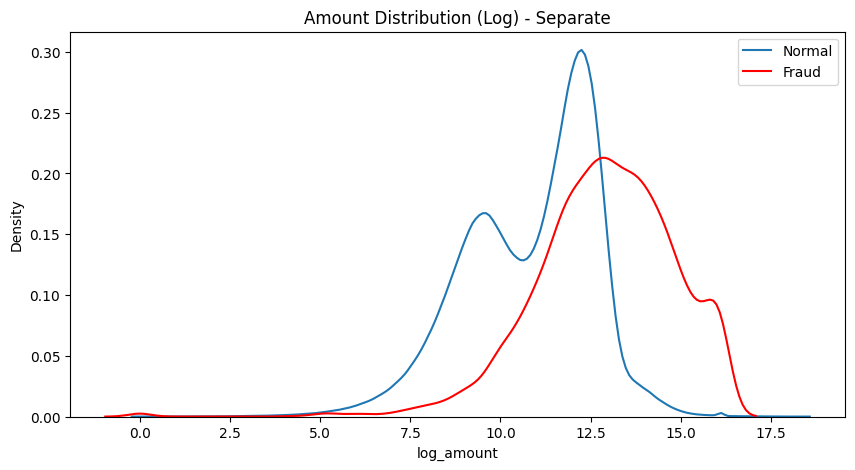

In [15]:
fraud = df[df['is_fraud']==1]
normal = df[df['is_fraud']==0]

plt.figure(figsize=(10,5))
sns.kdeplot(normal['log_amount'], label='Normal')
sns.kdeplot(fraud['log_amount'], label='Fraud', color='red')
plt.legend()
plt.title("Amount Distribution (Log) - Separate")
plt.show()

Fraud işlemler daha yüksek tutarlı
Normal işlemler daha düşük aralıkta yoğun

# Zaman - Tutar

In [16]:
import pandas as pd
from google.cloud import bigquery

full_table_path = 'data426-group3.money_fraud.time_midnight_fraud_base'

project_id = full_table_path.split('.')[0]

client = bigquery.Client(project=project_id)

query = f"""
SELECT
    transaction_id,
    amount,
    step,
    transaction_type,
    sender_id,
    receiver_id,
    is_fraud,
    day,
    hour,
    is_night,
    is_midnight,
    is_late_night,
    is_first_week,
    is_first_half_month
FROM `{full_table_path}`
"""

df = client.query(query).to_dataframe()


In [17]:
for col in df.columns:
    print(col)

transaction_id
amount
step
transaction_type
sender_id
receiver_id
is_fraud
day
hour
is_night
is_midnight
is_late_night
is_first_week
is_first_half_month


In [18]:
df.groupby('hour')['is_fraud'].mean()

,is_fraud
hour,
0,0.013205
1,0.041251
2,0.162431
3,0.22079
4,0.223035
5,0.104678
6,0.036493
7,0.013673
8,0.001203


In [19]:
df.groupby(['is_night'])['amount'].mean()

,amount
is_night,
0,179940.437449
1,168695.976340


In [20]:
df.groupby('high_amount_night')['is_fraud'].mean()

KeyError: 'high_amount_night'

In [ ]:
features = [
    'log_amount',
    'hour',
    'day',
    'is_night',
    'is_midnight',
    'high_amount',
    'high_amount_night'
]

X = df[features]
y = df['is_fraud']

In [21]:
#Gerekli kütüphaneler

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df.head()

,transaction_id,amount,step,transaction_type,sender_id,receiver_id,is_fraud,day,hour,is_night,is_midnight,is_late_night,is_first_week,is_first_half_month
0,TX_000003837,26279.17,3,CASH_IN,C21252030,C1364913072,0,1,2,1,1,1,1,1
1,TX_000004333,25752.66,4,CASH_IN,C586164630,C1303868418,0,1,3,1,1,1,1,1
2,TX_000005692,106019.41,6,CASH_IN,C1255723887,C1396827930,0,1,5,1,0,1,1,1
3,TX_000006673,51437.60,6,CASH_IN,C653292129,C481402298,0,1,5,1,0,1,1,1
4,TX_000012932,154516.48,7,CASH_IN,C530049590,C1255024717,0,1,6,0,0,0,1,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column               Dtype  
---  ------               -----  
 0   transaction_id       object 
 1   amount               float64
 2   step                 Int64  
 3   transaction_type     object 
 4   sender_id            object 
 5   receiver_id          object 
 6   is_fraud             Int64  
 7   day                  Int64  
 8   hour                 Int64  
 9   is_night             Int64  
 10  is_midnight          Int64  
 11  is_late_night        Int64  
 12  is_first_week        Int64  
 13  is_first_half_month  Int64  
dtypes: Int64(9), float64(1), object(4)
memory usage: 734.2+ MB


In [24]:
df['is_fraud'].value_counts(normalize=True)

,proportion
is_fraud,
0,0.998709
1,0.001291


In [25]:
drop_cols = [
    'transaction_id',          # ID, modele anlamlı sinyal vermez
    'fraud_scenario',          # leakage riski
    'scenario_group',          # leakage riski
    'is_original_fraud_label', # target ile doğrudan ilişkili
    'is_engineered_scenario'   # engineered fraud senaryosu, leakage riski
]

In [26]:
#log_amount
df['log_amount'] = np.log1p(df['amount'])

In [27]:
#high amount
df['high_amount'] = (df['amount'] > 200000).astype(int)

In [28]:
#Gece+yüksek tutar kombinasyonu
if 'is_night' in df.columns:
    df['high_amount_night'] = (
        (df['high_amount'] == 1) & (df['is_night'] == 1)
    ).astype(int)

In [29]:
#X & y
target = 'is_fraud'

X = df.drop(columns=[target])
y = df[target]

In [30]:
id_like_cols = ['sender_id', 'receiver_id']

id_like_existing = [col for col in id_like_cols if col in X.columns]
X = X.drop(columns=id_like_existing)

In [31]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32', 'bool']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['transaction_id', 'transaction_type']
Numeric columns: ['amount', 'step', 'day', 'hour', 'is_night', 'is_midnight', 'is_late_night', 'is_first_week', 'is_first_half_month', 'log_amount', 'high_amount', 'high_amount_night']


In [32]:
#Train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
#Kontrol
print("Train fraud ratio:")
print(y_train.value_counts(normalize=True))

print("Test fraud ratio:")
print(y_test.value_counts(normalize=True))

Train fraud ratio:
is_fraud
0    0.998709
1    0.001291
Name: proportion, dtype: Float64
Test fraud ratio:
is_fraud
0    0.998709
1    0.001291
Name: proportion, dtype: Float64


In [34]:
#Kategorik değişkenleri one-hot encode
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [35]:
#Model kurma
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)

In [36]:
#Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

In [37]:
#Model parametreleriyle tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

In [38]:
model = RandomForestClassifier(
    n_estimators=50,    # 🔻 düşür
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

In [39]:
search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=5,           # 🔻 20 yerine 5
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

In [ ]:
search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
